# Name: Shamir Maharjan
# Student ID: 2417731
# Workshop 7

## What is Autoencoder?

#### An autoencoder is a type of artificial neural network used to learn efficient representations of data,typically for the purpose of dimensionality reduction, feature extraction or Noise removal. Autoencoderare based on Encoder - Decoder style architecture.

## Structure of an Autoencoder:

### 1. Encoder:
• The encoder maps the input data X into a smaller representation, typically called the latent
space Z.

• The encoder learns to extract the most important features from the input data while ignoring
the less important ones.

Z = f(X)

### 2. Decoder:

• The decoder reconstructs the original input data from the encoded latent space representation.
    
• The decoder’s output in autoencoder is typically the same shape as the original input data.

X
′
= g(Z)

X
′ → is the reconstructed output.

## How Does an Autoencoder Work?

#### 1. Training the Autoencoder:

• During training, the network learns to compress the input data into compact representation
and then reconstruct it

• The model is trained to minimize the loss between the original input and the reconstructed
output.

• This means that the autoencoder tries to reproduce the original input as accurately as possible
after encoding and decoding.
    
### 2. Loss Function: 
The most common loss function used is mean squared error or binary cross
entropy.

• Mean Squared Error: Measures the squared difference between the input and the output,
i.e. how much the reconstructed image differs from the original.

• Binary Cross - Entropy: Commonly used when working with images where the pixel
values are normalized to the range: [0 − 1].

# Autoencoder: Denoising.

## Load, pre - process and add a Noise to the Dataset:

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from PIL import Image, UnidentifiedImageError
import matplotlib.image as mpimg
import random
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [8]:
train_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 7\\DevanagariHandwrittenDigitDataset\\Train"

test_dir = "C:\\Users\\LOQ\\semester 6\\AIML\\Workshop 7\\DevanagariHandwrittenDigitDataset\\Test"

train_class_names = sorted(os.listdir(train_dir))

if not train_class_names:
    print("No class directories found in training folder")
else:
    print(f"Found {len(train_class_names)} classes in train: {(train_class_names)}")

test_class_names = sorted(os.listdir(test_dir))

if not test_class_names:
    print("No class directories found in testing folder")
else:
    print(f"Found {len(test_class_names)} classes in test: {(test_class_names)}")

Found 10 classes in train: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Found 10 classes in test: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


## Check for corrupted images

In [9]:
train_corrupted_images = []

for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)  # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except ( IOError, UnidentifiedImageError):
                train_corrupted_images.append(img_path)

# Print results
if train_corrupted_images:
    print("\n Total corrupted images found is traning dataset:", len(train_corrupted_images))
    print("\nCorrupted Images Found in traning dataset:")
    for img in train_corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in traning dataset.")


No corrupted images found in traning dataset.


In [11]:
test_corrupted_images = []

for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)  # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except ( IOError, UnidentifiedImageError):
                test_corrupted_images.append(img_path)

# Print results
if test_corrupted_images:
    print("\n Total corrupted images found is testing dataset:", len(test_corrupted_images))
    print("\nCorrupted Images Found in testing dataset:")
    for img in test_corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in testing dataset.")


No corrupted images found in testing dataset.


## File Count Summary of Train Directory

In [12]:
total_train_image_count = 0

for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # os.listdir gets EVERY file in the folder
        images_in_folder = os.listdir(class_path) 
        total_train_image_count += len(images_in_folder)

print("--- TRAIN FILE COUNT SUMMARY --- \n")
print(f"Total images in folder (Valid + Corrupted): {total_train_image_count}")
print(f"Total Valid images:     {total_train_image_count - len(train_corrupted_images)}")
print(f"Total Corrupted images: {len(train_corrupted_images)}")

--- TRAIN FILE COUNT SUMMARY --- 

Total images in folder (Valid + Corrupted): 17000
Total Valid images:     17000
Total Corrupted images: 0


## File Count Summary of Train Directory

In [13]:
total_test_image_count = 0

for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        # os.listdir gets EVERY file in the folder
        images_in_folder = os.listdir(class_path) 
        total_test_image_count += len(images_in_folder)

print("--- TEST FILE COUNT SUMMARY --- \n")
print(f"Total images in folder (Valid + Corrupted): {total_test_image_count}")
print(f"Total Valid images:     {total_test_image_count - len(test_corrupted_images)}")
print(f"Total Corrupted images: {len(test_corrupted_images)}")

--- TEST FILE COUNT SUMMARY --- 

Total images in folder (Valid + Corrupted): 3000
Total Valid images:     3000
Total Corrupted images: 0


## Train Dataset Statistics

In [14]:
train_image_stats = []

print("Scanning valid images of train directory to calculate shapes, widths, heights, and channels...")

for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            
            # Skip the corrupted images 
            if img_path in train_corrupted_images:
                continue
                
            try:
                with Image.open(img_path) as img:
                    # Get Width and Height
                    width, height = img.size
                    
                    #  Get Channels based on the image "mode"
                    # RGB = 3 channels (Color)
                    # L = 1 channel (Grayscale)
                    mode = img.mode
                    if mode == 'RGB':
                        channels = 3
                    elif mode == 'L':
                        channels = 1
                    else:
                        channels = mode # Just in case it's a weird format
                        
                    # Add to our list
                    train_image_stats.append({
                        'class': class_name,
                        'width': width,
                        'height': height,
                        'channels': channels
                    })
            except Exception as e:
                pass # Just in case there's another file error

df_train_stats = pd.DataFrame(train_image_stats)

print("\n--- TRAIN DATASET STATISTICS ---")

# Total number of images
print(f"Total valid images: {len(df_train_stats)}")

# Image shapes summary
print("\nUnique Image Shapes (Width x Height x Channels):")

# Create a 'shape' column just for easy viewing
df_train_stats['shape'] = df_train_stats['width'].astype(str) + " x " + df_train_stats['height'].astype(str) + " x " + df_train_stats['channels'].astype(str)
print(df_train_stats['shape'].value_counts())

# Width and Height ranges (Min, Max, Average)
print("\nResolution Summary:")
print(f"Width:  Min = {df_train_stats['width'].min()}, Max = {df_train_stats['width'].max()}, Average = {int(df_train_stats['width'].mean())}")
print(f"Height: Min = {df_train_stats['height'].min()}, Max = {df_train_stats['height'].max()}, Average = {int(df_train_stats['height'].mean())}")

# Channel summary
print("\nChannels Summary:")
print(df_train_stats['channels'].value_counts())

Scanning valid images of train directory to calculate shapes, widths, heights, and channels...

--- TRAIN DATASET STATISTICS ---
Total valid images: 17000

Unique Image Shapes (Width x Height x Channels):
shape
32 x 32 x 1    17000
Name: count, dtype: int64

Resolution Summary:
Width:  Min = 32, Max = 32, Average = 32
Height: Min = 32, Max = 32, Average = 32

Channels Summary:
channels
1    17000
Name: count, dtype: int64


## Test Dataset Statistics

In [15]:
test_image_stats = []

print("Scanning valid images of test directory to calculate shapes, widths, heights, and channels...")

for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            
            # Skip the corrupted images 
            if img_path in test_corrupted_images:
                continue
                
            try:
                with Image.open(img_path) as img:
                    # Get Width and Height
                    width, height = img.size
                    
                    #  Get Channels based on the image "mode"
                    # RGB = 3 channels (Color)
                    # L = 1 channel (Grayscale)
                    mode = img.mode
                    if mode == 'RGB':
                        channels = 3
                    elif mode == 'L':
                        channels = 1
                    else:
                        channels = mode # Just in case it's a weird format
                        
                    # Add to our list
                    test_image_stats.append({
                        'class': class_name,
                        'width': width,
                        'height': height,
                        'channels': channels
                    })
            except Exception as e:
                pass # Just in case there's another file error


df_test_stats = pd.DataFrame(test_image_stats)

print("\n--- TEST DATASET STATISTICS ---")

# Total number of images
print(f"Total valid images: {len(df_test_stats )}")

# Image shapes summary
print("\nUnique Image Shapes (Width x Height x Channels):")
# Create a 'shape' column just for easy viewing
df_test_stats ['shape'] = df_test_stats ['width'].astype(str) + " x " + df_test_stats ['height'].astype(str) + " x " + df_test_stats ['channels'].astype(str)
print(df_test_stats ['shape'].value_counts())

# Width and Height ranges (Min, Max, Average)
print("\nResolution Summary:")
print(f"Width:  Min = {df_test_stats ['width'].min()}, Max = {df_test_stats ['width'].max()}, Average = {int(df_test_stats ['width'].mean())}")
print(f"Height: Min = {df_test_stats ['height'].min()}, Max = {df_test_stats ['height'].max()}, Average = {int(df_test_stats ['height'].mean())}")

# Channel summary
print("\nChannels Summary:")
print(df_test_stats ['channels'].value_counts())

Scanning valid images of test directory to calculate shapes, widths, heights, and channels...

--- TEST DATASET STATISTICS ---
Total valid images: 3000

Unique Image Shapes (Width x Height x Channels):
shape
32 x 32 x 1    3000
Name: count, dtype: int64

Resolution Summary:
Width:  Min = 32, Max = 32, Average = 32
Height: Min = 32, Max = 32, Average = 32

Channels Summary:
channels
1    3000
Name: count, dtype: int64


## Count class Balance for Traning Dataset:

In [16]:
# Dictionary to store class counts
class_counts = {}
for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution of training dataset:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution of training dataset:
Class Name               Valid Image Count
digit_0                             1700
digit_1                             1700
digit_2                             1700
digit_3                             1700
digit_4                             1700
digit_5                             1700
digit_6                             1700
digit_7                             1700
digit_8                             1700
digit_9                             1700


## Count class Balance for Testing Dataset:

In [17]:
# Dictionary to store class counts
class_counts = {}
for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution of testing dataset:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution of testing dataset:
Class Name               Valid Image Count
digit_0                              300
digit_1                              300
digit_2                              300
digit_3                              300
digit_4                              300
digit_5                              300
digit_6                              300
digit_7                              300
digit_8                              300
digit_9                              300


## Select Random Images for Visualization:

In [20]:
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in train_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

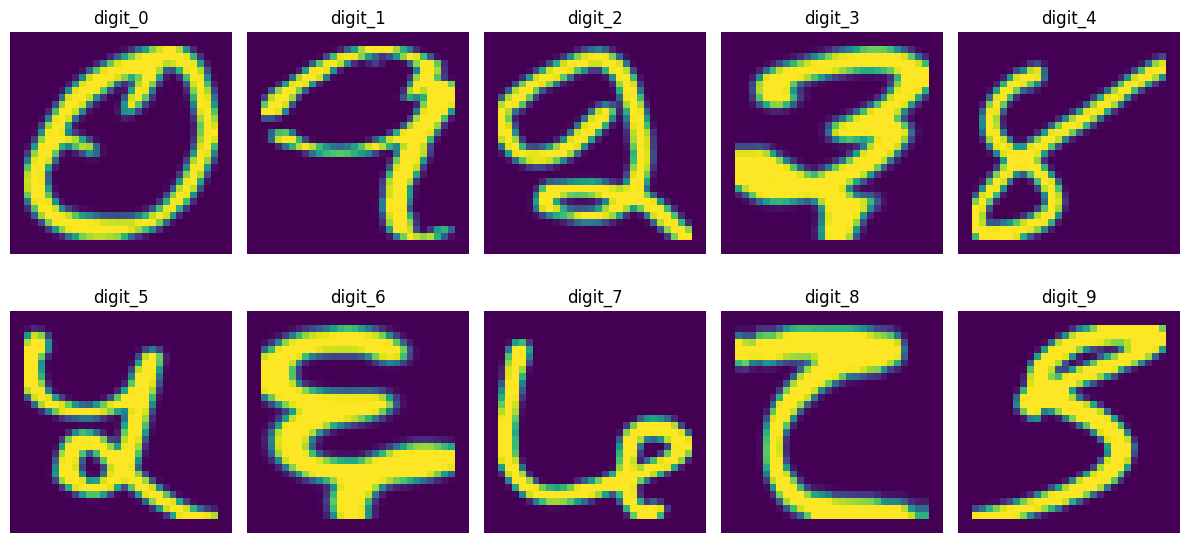

In [21]:
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

## Data Generation and Pre - processing:

In [23]:
IMG_SIZE = (32, 32)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42
NOISE_STDDEV = 0.1

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',      
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='training',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset='validation',
    shuffle=True
)


def normalize_and_reshape(images, labels):
    # Cast to float32 and normalize to [0, 1]
    images = tf.cast(images, tf.float32) / 255.0
    # Explicitly ensure shape: (batch, 32, 32, 1)
    images = tf.reshape(images, [-1, IMG_SIZE[0], IMG_SIZE[1], 1])
    return images, labels

train_ds = train_ds.map(normalize_and_reshape, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(normalize_and_reshape, num_parallel_calls=tf.data.AUTOTUNE)

def add_gaussian_noise(images, labels, stddev=NOISE_STDDEV):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=stddev)
    noisy = tf.clip_by_value(images + noise, 0.0, 1.0)
    return noisy, images  # x = noisy, y = clean (target)

train_ds = train_ds.map(lambda x, y: add_gaussian_noise(x, y, stddev=NOISE_STDDEV))
val_ds   = val_ds.map(lambda x, y: add_gaussian_noise(x, y, stddev=NOISE_STDDEV))


Found 17000 files belonging to 10 classes.
Using 13600 files for training.
Found 17000 files belonging to 10 classes.
Using 3400 files for validation.


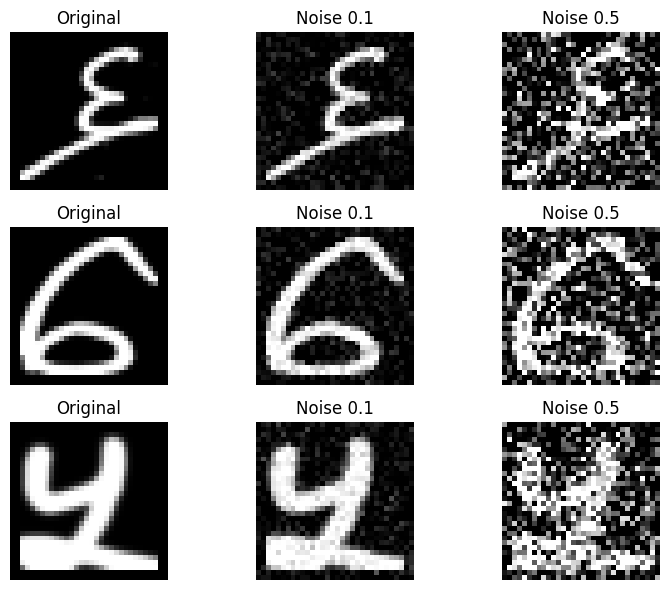

In [26]:
batch = next(iter(train_ds))
noisy_images, clean_images = batch

sample_indices = [0, 1, 2]

plt.figure(figsize=(8, 6))

for i, idx in enumerate(sample_indices):

    original_img = np.squeeze(clean_images[idx].numpy())
    
    noise_01 = np.random.normal(loc=0.0, scale=0.1, size=original_img.shape)
    img_01 = np.clip(original_img + noise_01, 0.0, 1.0)
    
    noise_05 = np.random.normal(loc=0.0, scale=0.5, size=original_img.shape)
    img_05 = np.clip(original_img + noise_05, 0.0, 1.0)
    
    images = [original_img, img_01, img_05]
    titles = ["Original", "Noise 0.1", "Noise 0.5"]
    
    for j in range(3):
        plt.subplot(3, 3, i * 3 + j + 1)
        plt.imshow(images[j], cmap='gray')
        plt.title(titles[j])
        plt.axis('off')

plt.tight_layout()
plt.show()

# Build the Convolutional Denoising Autoencoder Model:

### Encoder:
– Convolutional Layers + ReLU activation.

– Maxpooling to down-sample the features.
    
### • Decoder:
– Convolutional layers + ReLU activation.

– Upsampling to upsample the feature maps.
    
– Final Layer with sigmoid activation to keep output pixels in range [0, 1].

• Transpose Convolutional is achieved in Keras using convolutional and Upsampling
operations.

• Compile the Model with binary crossentropy loss and ADAM optimizer.

## Building Encoder

In [29]:
def build_encoder(input_shape=(32, 32, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    Parameters:
    input_shape (tuple): Shape of the input image. Default is (32, 32, 1) 
    Returns:
    input_img (Keras Input): Input layer of the model.
    encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

### Building Decoder

In [30]:
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    Parameters:
    encoded_input (Keras Tensor): The output from the encoder.
    Returns:
    decoded (Keras Tensor): The reconstructed output after upsampling and
    convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

### Building Autoencdoder

In [31]:
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
    autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

### Compile the Model

In [34]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoded (MaxPooling2D)               │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoded (Conv2D)                     │ (None, 32, 32, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Autoencoder:

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_autoencoder.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


EPOCHS = 20
BATCH_SIZE = 32

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


Epoch 1/20
422/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2221
Epoch 1: val_loss improved from None to 0.12261, saving model to best_autoencoder.h5



Epoch 1: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.1552 - val_loss: 0.1226
Epoch 2/20
422/425 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1215
Epoch 2: val_loss improved from 0.12261 to 0.11750, saving model to best_autoencoder.h5



Epoch 2: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1201 - val_loss: 0.1175
Epoch 3/20
422/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1171
Epoch 3: val_loss improved from 0.11750 to 0.11587, saving model to best_autoencoder.h5



Epoch 3: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1168 - val_loss: 0.1159
Epoch 4/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1155
Epoch 4: val_loss improved from 0.11587 to 0.11410, saving model to best_autoencoder.h5



Epoch 4: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1152 - val_loss: 0.1141
Epoch 5/20
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1142
Epoch 5: val_loss improved from 0.11410 to 0.11327, saving model to best_autoencoder.h5


...


Epoch 14: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1106 - val_loss: 0.1102
Epoch 15/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1103
Epoch 15: val_loss improved from 0.11020 to 0.10994, saving model to best_autoencoder.h5



Epoch 15: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1104 - val_loss: 0.1099
Epoch 16/20
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1101
Epoch 16: val_loss did not improve from 0.10994
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1102 - val_loss: 0.1104
Epoch 17/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1100
Epoch 17: val_loss improved from 0.10994 to 0.10977, saving model to best_autoencoder.h5



Epoch 17: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1101 - val_loss: 0.1098
Epoch 18/20
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1097
Epoch 18: val_loss did not improve from 0.10977
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1099 - val_loss: 0.1099
Epoch 19/20
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1097
Epoch 19: val_loss improved from 0.10977 to 0.10957, saving model to best_autoencoder.h5



Epoch 19: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1098 - val_loss: 0.1096
Epoch 20/20
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1097
Epoch 20: val_loss improved from 0.10957 to 0.10953, saving model to best_autoencoder.h5



Epoch 20: finished saving model to best_autoencoder.h5
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.1098 - val_loss: 0.1095
Restoring model weights from the end of the best epoch: 20.


### Plot Loss Curve

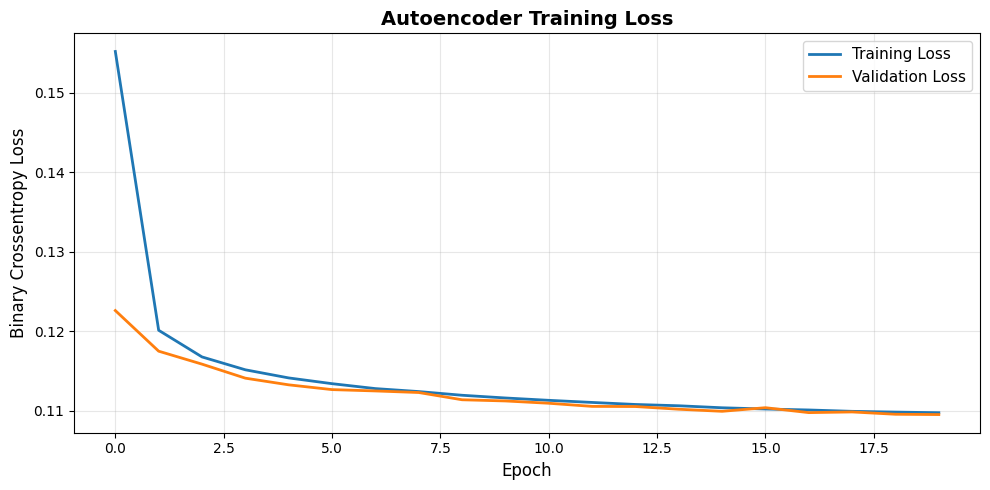

In [36]:
plt.figure(figsize=(10, 5))

# Training and Validation Loss
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Autoencoder Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate and Visualize the Results:

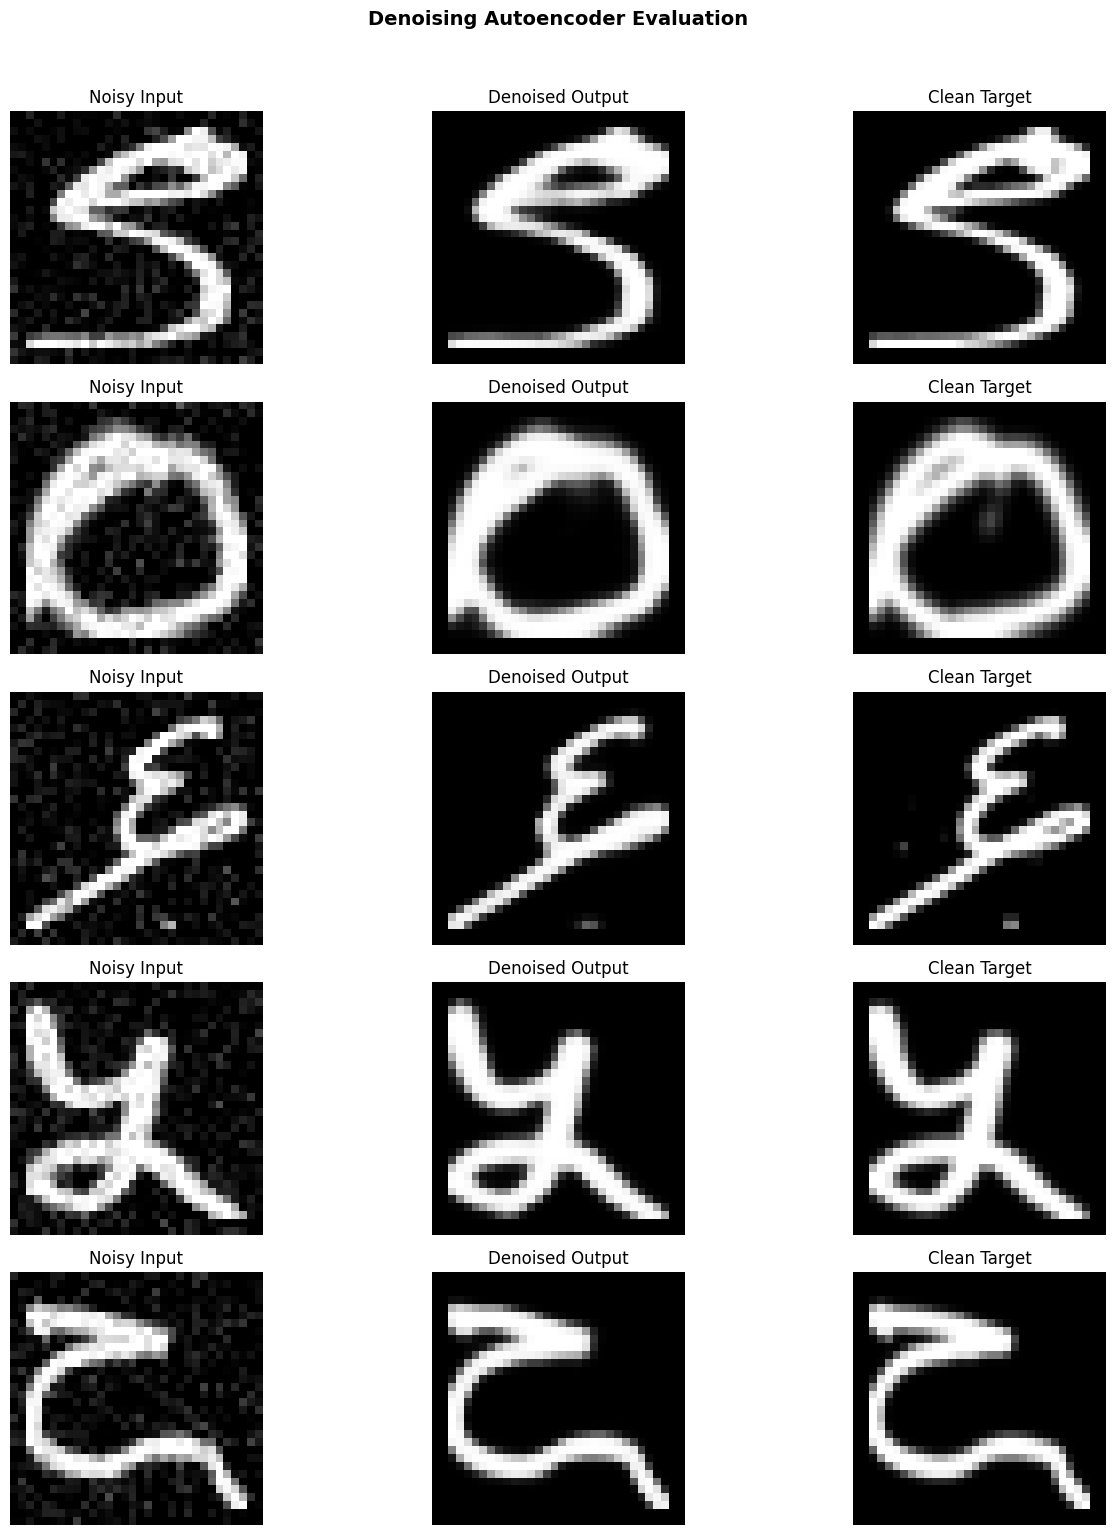

In [41]:
# Fetch a single batch from the validation set (unseen during training)
noisy_batch, clean_batch = next(iter(val_ds))

# Pass noisy images through the trained autoencoder
denoised_batch = autoencoder.predict(noisy_batch, verbose=0)

# Select random samples to display
n_samples = 5
sample_indices = np.random.choice(noisy_batch.shape[0], n_samples, replace=False)

plt.figure(figsize=(14, 3 * n_samples))

for i, idx in enumerate(sample_indices):
    # Remove channel dimension & convert to numpy
    noisy_img = np.squeeze(noisy_batch[idx].numpy())
    clean_img = np.squeeze(clean_batch[idx].numpy())
    denoised_img = np.squeeze(denoised_batch[idx])
    
    images = [noisy_img, denoised_img, clean_img]
    titles = ["Noisy Input", "Denoised Output", "Clean Target"]
    
    for j in range(3):
        plt.subplot(n_samples, 3, i * 3 + j + 1)
        plt.imshow(images[j], cmap='gray')
        plt.title(titles[j])
        plt.axis('off')

plt.suptitle("Denoising Autoencoder Evaluation", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()